# FUNCTION TRANSFORMER

Function Transformation is a feature engineering technique in Machine Learning where we apply a mathematical function to a feature (column) to make its distribution more suitable for ML algorithms.

For Normal Distribution

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import numpy as np

In [2]:

dataset = pd.read_csv(r"C:\Users\SHAMSHER\Downloads\student-lifestyle-and-stress-dataset.csv")
dataset.head(3)

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1,12.0,1


In [3]:
dataset.isnull().sum()

Student_Type          1252
Sleep_Hours           1333
Study_Hours           1277
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

In [4]:
dataset['Attendance'].fillna(dataset['Attendance'].mean(),inplace=True)

C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_25888\840048719.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Attendance'].fillna(dataset['Attendance'].mean(),inplace=True)


C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_25888\3975375322.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Attendance'])


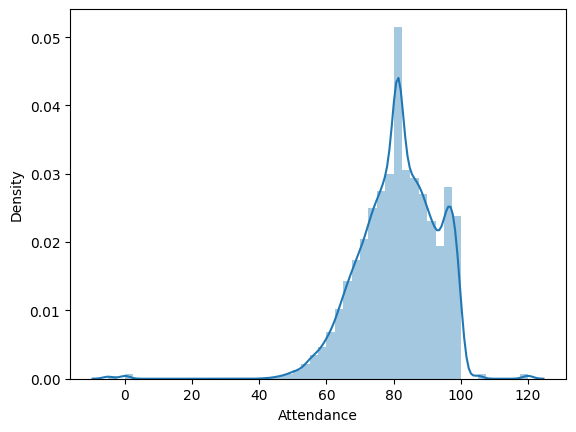

In [5]:
sns.distplot(dataset['Attendance'])
plt.show()

<Axes: xlabel='Attendance'>

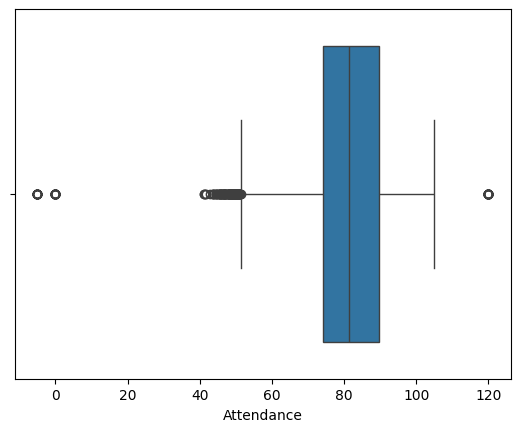

In [6]:
sns.boxplot(x=dataset['Attendance'])

In [7]:
q1 = dataset['Attendance'].quantile(0.25)
q3 = dataset['Attendance'].quantile(0.75)
q1,q3

(np.float64(74.2833160675), np.float64(89.583237035))

In [8]:
IQR = q3-q1
IQR

np.float64(15.2999209675)

In [9]:
min_range = q1-(1.5*IQR)
max_range = q3+(1.5*IQR)
min_range,max_range

(np.float64(51.333434616249995), np.float64(112.53311848625))

In [10]:
dataset=dataset[dataset['Attendance']>=min_range]
dataset=dataset[dataset['Attendance']<=max_range]

<Axes: xlabel='Attendance'>

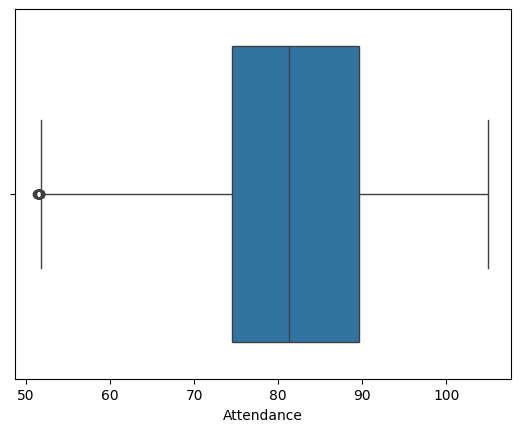

In [11]:
sns.boxplot(x=dataset['Attendance'])

C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_25888\2806746388.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=dataset['Attendance'])


<Axes: ylabel='Density'>

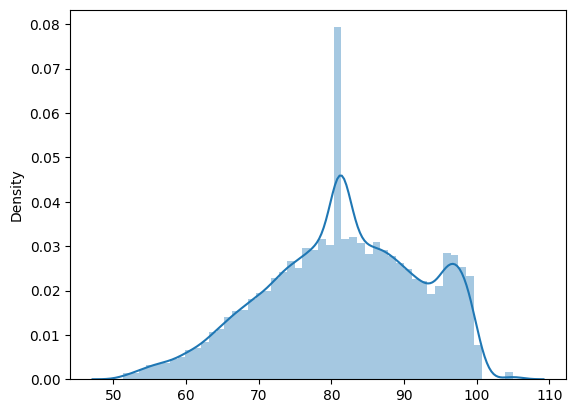

In [12]:
sns.distplot(x=dataset['Attendance'])

In [13]:
from sklearn.preprocessing import FunctionTransformer

In [14]:
ft = FunctionTransformer(func=np.log1p)

In [15]:
ft.fit(dataset[['Attendance']])

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log1p'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` has featurenames that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Attendance']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1


In [16]:
dataset['Attendance_tf'] = ft.transform(dataset[['Attendance']])

C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_25888\3603755358.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=dataset['Attendance'])
C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_25888\3603755358.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=dataset['Attendance_tf'])


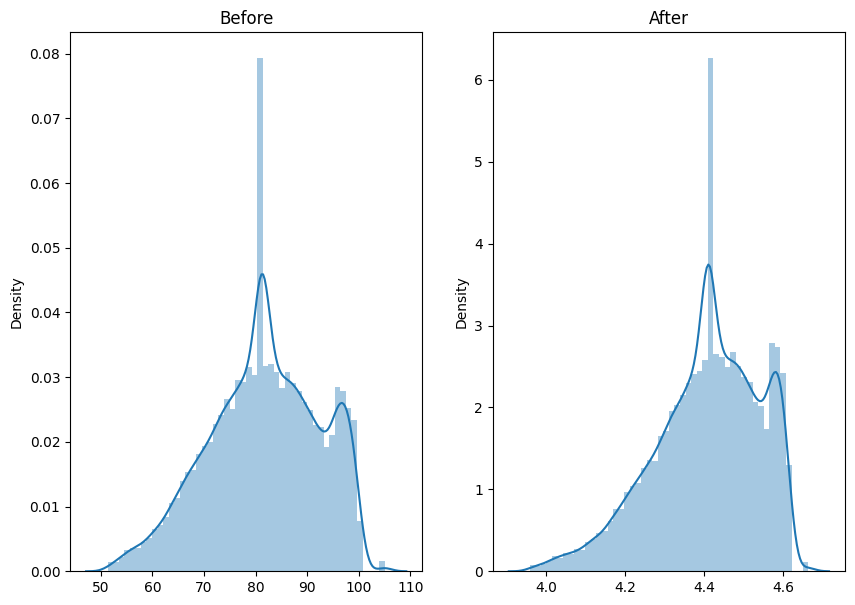

In [17]:
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
sns.distplot(x=dataset['Attendance'])
plt.title("Before")

plt.subplot(1,2,2)
sns.distplot(x=dataset['Attendance_tf'])
plt.title("After")
plt.show()

In [18]:
# tf1 = FunctionTransformer(func= lambda x : x**2)
# tf1.fit(dataset['Attendance'])
# dataset['Attendance_tf1'] = tf1.transform(dataset['Attendance'])

In [ ]:
# plt.figure(figsize=(10,7))
# plt.subplot(1,2,1)
# sns.distplot(x=dataset['Attendance'])
# plt.title("Before")

# plt.subplot(1,2,2)
# sns.distplot(x=dataset['Attendance_tf1'])
# plt.title("After")
# plt.show()